# Analiza i kategoryzacja płciowa zapachów typu unisex z wykorzystaniem algorytmu Random Forest
Dane zostały zescrapowane z największego perfumowego forum `(https://www.fragrantica.com)`. Plik `raw_data.csv` zawiera dane dotyczące ponad 5400 zapachów męskich i unisex.

Moim celem jest analiza oraz kategoryzacja perfum bez podziału na płeć. Zapachy typu **unisex** często wbrew ich założeniu są bardziej męskie lub damskie. Z tego powodu chcę zobaczyć jaki wpływ mają dane akordy na ten podział.

Informacje dotyczące dla kogo kierowany jest dany perfum, na których bazuję swoją analizę oraz kategoryzację opieram na opiniach użytkowników forum.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

columns = [
    "url", "name", "brand", "rating", "votes_count", "main_accords",
    "top_notes", "middle_notes", "base_notes", "longevity", "sillage",
    "gender_votes", "price_value", "reminds_me_of"
]
# Otwierania pliku oraz nadanie kolumnom etykiet
raw_data = pd.read_csv("raw_data.csv", names=columns, header=0)
display(raw_data.head())

,url,name,brand,rating,votes_count,main_accords,top_notes,middle_notes,base_notes,longevity,sillage,gender_votes,price_value,reminds_me_of
0,https://www.fragrantica.com/perfume/Afnan/Supr...,Supremacy Collector's Edition Pour Homme Afnan...,Afnan,4.51,5571,"{""fruity"": 100.0, ""sweet"": 90.8802, ""white flo...","{""Pineapple"": 1.0, ""Bergamot"": 0.956719, ""Whit...","{""Orange Blossom"": 0.877573, ""Birch"": 0.810072...","{""oak moss"": 0.923236, ""Musk"": 0.835555, ""Ambe...","{""very weak"": 37, ""weak"": 54, ""moderate"": 645,...","{""intimate"": 102, ""moderate"": 1100, ""strong"": ...","{""female"": 50, ""more female"": 13, ""unisex"": 22...","{""way overpriced"": 63, ""overpriced"": 91, ""ok"":...","[{""name"": ""Absolu Aventus 2023"", ""brand"": ""CRE..."
1,https://www.fragrantica.com/perfume/French-Ave...,Vulcan Feu French Avenue for women and men,French Avenue,4.47,3711,"{""tropical"": 100.0, ""fruity"": 98.7049, ""sweet""...","{""Mango"": 1.0, ""Lemon"": 0.967204, ""Ginger"": 0....","{""Pink Pepper"": 0.82556, ""Jasmine"": 0.7994, ""V...","{""Tonka Bean"": 0.845299, ""Cedarwood"": 0.830589...","{""very weak"": 31, ""weak"": 61, ""moderate"": 679,...","{""intimate"": 102, ""moderate"": 1100, ""strong"": ...","{""female"": 102, ""more female"": 165, ""unisex"": ...","{""way overpriced"": 37, ""overpriced"": 56, ""ok"":...","[{""name"": ""God of Fire"", ""brand"": ""STÉPHANE HU..."
2,https://www.fragrantica.com/perfume/Hugo-Boss/...,Bottled Absolu Hugo Boss for men,Hugo Boss,4.46,5295,"{""amber"": 100.0, ""woody"": 81.8837, ""balsamic"":...","{""Incense"": 1.0, ""Leather"": 1.0}","{""Patchouli"": 1.0, ""Myrrh"": 1.0}","{""Cedarwood"": 0.911338, ""Davana"": 0.735089}","{""very weak"": 25, ""weak"": 38, ""moderate"": 454,...","{""intimate"": 65, ""moderate"": 894, ""strong"": 23...","{""female"": 43, ""more female"": 12, ""unisex"": 14...","{""way overpriced"": 96, ""overpriced"": 351, ""ok""...","[{""name"": ""Carlisle"", ""brand"": ""PARFUMS DE MAR..."
3,https://www.fragrantica.com/perfume/Jean-Paul-...,Le Beau Paradise Garden Jean Paul Gaultier for...,Jean Paul Gaultier,4.32,10083,"{""green"": 100.0, ""coconut"": 83.5093, ""sweet"": ...","{""Green Notes"": 1.0, ""Watery Notes"": 0.942228,...","{""Coconut"": 1.0, ""Fig"": 0.96025, ""Salt"": 0.7994}","{""Tonka Bean"": 0.8906, ""Sandalwood"": 0.873128}","{""very weak"": 104, ""weak"": 198, ""moderate"": 23...","{""intimate"": 323, ""moderate"": 3800, ""strong"": ...","{""female"": 97, ""more female"": 31, ""unisex"": 11...","{""way overpriced"": 281, ""overpriced"": 1300, ""o...","[{""name"": ""Le Beau"", ""brand"": ""JEAN PAUL GAULT..."
4,https://www.fragrantica.com/perfume/Lattafa-Pe...,Angham Lattafa Perfumes for women and men,Lattafa Perfumes,4.48,4185,"{""vanilla"": 100.0, ""sweet"": 90.2807, ""lavender...","{""Ginger"": 0.881966, ""Mandarin"": 0.782839, ""Pi...","{""Lavender"": 1.0, ""Praline"": 0.886308, ""Cacao""...","{""Vanilla"": 1.0, ""Amber"": 0.82556, ""Musk"": 0.7...","{""very weak"": 77, ""weak"": 198, ""moderate"": 140...","{""intimate"": 284, ""moderate"": 1500, ""strong"": ...","{""female"": 1700, ""more female"": 707, ""unisex"":...","{""way overpriced"": 38, ""overpriced"": 37, ""ok"":...","[{""name"": ""Goddess"", ""brand"": ""BURBERRY"", ""upv..."


In [ ]:
# Przefiltrowanie danych - tylko perfumy unisex, ich akordy oraz głosy społeczności na płeć odbiorcy
mask1 = raw_data['name'].str.contains("women and men")
filtered_data = raw_data[mask1][["name", "main_accords", "gender_votes"]]
display(filtered_data)

,name,main_accords,gender_votes
1,Vulcan Feu French Avenue for women and men,"{""tropical"": 100.0, ""fruity"": 98.7049, ""sweet""...","{""female"": 102, ""more female"": 165, ""unisex"": ..."
4,Angham Lattafa Perfumes for women and men,"{""vanilla"": 100.0, ""sweet"": 90.2807, ""lavender...","{""female"": 1700, ""more female"": 707, ""unisex"":..."
6,Teriaq Intense Lattafa Perfumes for women and men,"{""amber"": 100.0, ""warm spicy"": 98.8878, ""fruit...","{""female"": 222, ""more female"": 339, ""unisex"": ..."
8,Amber Oud Aqua Dubai Al Haramain Perfumes for ...,"{""citrus"": 100.0, ""green"": 89.5041, ""aromatic""...","{""female"": 45, ""more female"": 22, ""unisex"": 60..."
10,Tilia Marc-Antoine Barrois for women and men,"{""yellow floral"": 100.0, ""white floral"": 80.37...","{""female"": 1500, ""more female"": 698, ""unisex"":..."
...,...,...,...
5404,Un Bois Sepia Serge Lutens for women and men,"{""woody"": 100.0, ""aromatic"": 65.3971, ""balsami...","{""female"": 1, ""more female"": 0, ""unisex"": 5, ""..."
5405,Eau des Délices Le Jardin Retrouve for women a...,"{""citrus"": 100.0, ""aromatic"": 53.8045, ""fresh ...","{""female"": 2, ""more female"": 2, ""unisex"": 21, ..."
5406,Donna Lorenzo Villoresi for women and men,"{""floral"": 100.0, ""rose"": 88.0569, ""warm spicy...","{""female"": 19, ""more female"": 7, ""unisex"": 9, ..."
5407,Soleil Blanc Tom Ford for women and men,"{""white floral"": 100.0, ""coconut"": 94.4569, ""s...","{""female"": 1200, ""more female"": 1000, ""unisex""..."


# Przetwarzanie i wektoryzacja danych

Na tym etapie przekształcam surowe dane tekstowe w format numeryczny. Wykorzystuję bibliotekę `ast` do sparsowania słowników ukrytych w tekście, co pozwala na stworzenie macierzy akordów zapachowych.

Kluczowym elementem jest stworzenie zmiennej objaśnianej `gender_score`. Obliczam ją jako średnią ważoną głosów społeczności, gdzie każda kategoria (od 'female' do 'male') ma przypisaną wagę od 0 do 4. Na koniec filtruję zestaw danych, pozostawiając jedynie te zapachy, które otrzymały minimum 100 głosów.

Po przefiltrowaniu zostało 2908 zapachów.

In [ ]:
# Funkcja, która zmienia JSONowa strukturę na słownik
def parse_dict(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return {}

data_subset = filtered_data.reset_index(drop=True)

# Użycie wcześniej zdefiniowanej funkcji
accords_series = data_subset['main_accords'].apply(parse_dict)
gender_series = data_subset['gender_votes'].apply(parse_dict)

# Stworzenie DataFramow i stworenie list z serii danych oraz wypełnienie pusty wartości zerami
accords_df = pd.DataFrame(accords_series.tolist()).fillna(0)
gender_df = pd.DataFrame(gender_series.tolist()).fillna(0)

# Ujednolicenie zapisu akordów oraz posortowanie ich alfabetycznie
accords_df = accords_df.reindex(sorted(accords_df.columns, key=str.lower), axis=1)

# Suma wszystkich głosów na płcie
total_gender_votes = gender_df.sum(axis=1)

# Stworzenie zmiennej, która przyjmuje wartości od 0 do 4, 0 - perfumy typowo kobiece, 4 - typowo męskie. Głosy przemnożono przez wagi i podzielono przez ich łączną ilość.
weights = {'female': 0, 'more female': 1, 'unisex': 2, 'more male': 3, 'male': 4}
weighted_sum = sum(gender_df[cat] * weights[cat] for cat in weights if cat in gender_df.columns)
gender_score = (weighted_sum / total_gender_votes).rename('gender_score')

# Zwektoryzowane dane
vectorized_data = pd.concat([data_subset[['name']], accords_df, gender_score], axis=1)

# Nie bierzemy pod uwagę perfum o ilości głosów mniejszej niż 100
result = vectorized_data[total_gender_votes > 100]

print("Zwektoryzowane dane:")
display(result.head())

# Kolumna nazwa nie będzie potrzebna później, jedynie wektor akordów oraz gender_score będzie wykorzystany w Random Forest Regressor.
result_numerical = result.drop(columns=['name'])
display(result_numerical.head())
print(result_numerical.shape)

Zwektoryzowane dane:


,name,alcohol,aldehydic,almond,amber,animalic,anis,aquatic,aromatic,asphault,...,violet,vodka,warm spicy,wet plaster,whiskey,white floral,wine,woody,yellow floral,gender_score
0,Vulcan Feu French Avenue for women and men,0.0,0.0,0.0,52.5383,0.0,0.0,0.0,54.9442,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,57.566,0.0,2.267021
1,Angham Lattafa Perfumes for women and men,0.0,0.0,0.0,57.2436,0.0,0.0,0.0,51.2568,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.000,0.0,0.551489
2,Teriaq Intense Lattafa Perfumes for women and men,0.0,0.0,0.0,100.0000,0.0,0.0,0.0,67.4591,0.0,...,0.0,0.0,98.8878,0.0,0.0,0.0000,0.0,0.000,0.0,2.005405
3,Amber Oud Aqua Dubai Al Haramain Perfumes for ...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,56.6666,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.000,0.0,2.817638
4,Tilia Marc-Antoine Barrois for women and men,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0,...,0.0,0.0,0.0000,0.0,0.0,80.3727,0.0,0.000,100.0,0.784506


,alcohol,aldehydic,almond,amber,animalic,anis,aquatic,aromatic,asphault,balsamic,...,violet,vodka,warm spicy,wet plaster,whiskey,white floral,wine,woody,yellow floral,gender_score
0,0.0,0.0,0.0,52.5383,0.0,0.0,0.0,54.9442,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,57.566,0.0,2.267021
1,0.0,0.0,0.0,57.2436,0.0,0.0,0.0,51.2568,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.000,0.0,0.551489
2,0.0,0.0,0.0,100.0000,0.0,0.0,0.0,67.4591,0.0,0.0,...,0.0,0.0,98.8878,0.0,0.0,0.0000,0.0,0.000,0.0,2.005405
3,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,56.6666,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0000,0.0,0.000,0.0,2.817638
4,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,80.3727,0.0,0.000,100.0,0.784506


(2908, 87)


# Algorytm *Random Forest Regressor*, nakarmienie go danymi, uczenie oraz wyniki

Korzystam z wariantu **Regressor**, ponieważ przewiduję wynik w skali ciągłej (od 0 do 4). **Random Forest** składa się z wielu drzew decyzyjnych, a jego ostateczny wynik to średnia z ich przewidywań. Las jest stabilniejszy od pojedynczego drzewa oraz daje lepszy współczynnik determinacji $R^2$.

In [ ]:
# X - akordy
X = result_numerical.drop(columns=['gender_score'])

# y - gender_score
y = result_numerical['gender_score']

# Podzielenie danych na dane testowe i treningowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=76)

print(f"Rozmiar cech (X): {X.shape}")
print(f"Rozmiar etykiet (y): {y.shape}")

# Inicjalizacja modelu
model = RandomForestRegressor(n_estimators=100, random_state=76)

# Trenowanie modelu
model.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred = model.predict(X_test)

# Ewaluacja modelu,
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Rozmiar cech (X): (2908, 86)
Rozmiar etykiet (y): (2908,)
Mean Squared Error (MSE): 0.2143
R^2 Score: 0.6459


## Wizualizacja wyników i analiza cech

W tej sekcji analizuję rozkład wyliczonego wskaźnika płci oraz sprawdzam, które akordy zapachowe są najważniejsze dla modelu przy określaniu profilu zapachu.

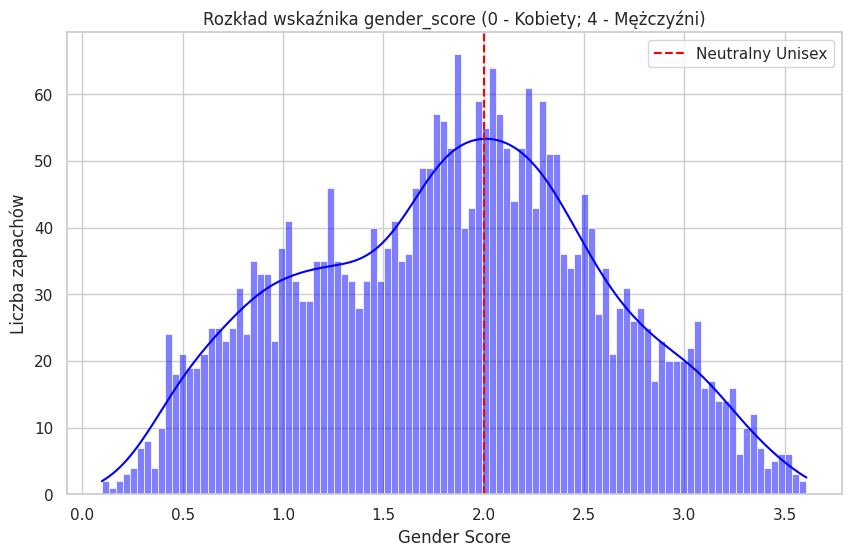

In [ ]:
# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Wykres rozkładu gender_score
sns.histplot(result['gender_score'], bins=100, kde=True, color='blue')
plt.title('Rozkład wskaźnika gender_score (0 - Kobiety; 4 - Mężczyźni)')
plt.xlabel('Gender Score')
plt.ylabel('Liczba zapachów')
plt.axvline(2.0, color='red', linestyle='--', label='Neutralny Unisex')
plt.legend()
plt.show()

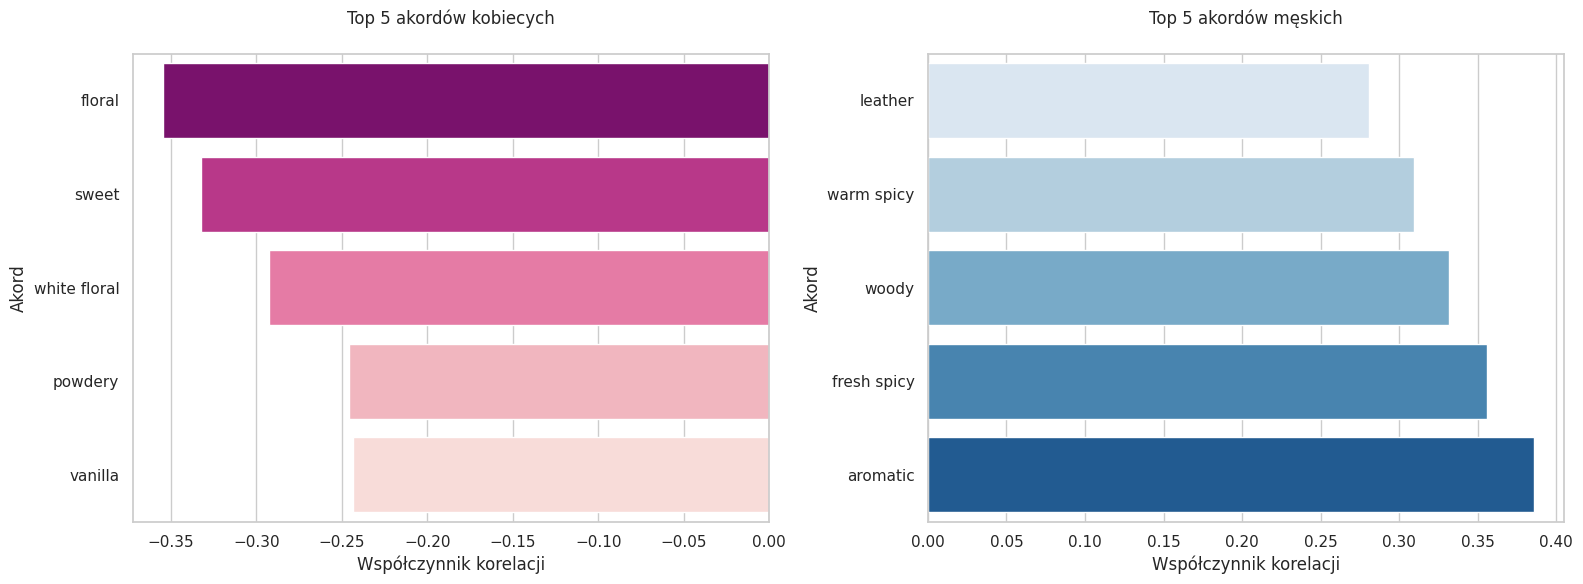

In [ ]:
# W ilu perfumach występuje dany akord
accord_counts = (X > 0).sum()

# Akordy, które występują w mniej niż 10 perfumach nie są brane pod uwagę
popular_accords = accord_counts[accord_counts >= 10].index

# Korelacja akordów i gender_score
correlations = result_numerical[list(popular_accords) + ['gender_score']].corr()['gender_score'].drop('gender_score').sort_values()

# Wybór top 5 dla obu płci
female_accords = correlations.head(5)
male_accords = correlations.tail(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Wykres dla kobiet
sns.barplot(x=female_accords.values, y=female_accords.index, ax=ax1, palette="RdPu_r", hue=female_accords.index, legend=False)
ax1.set_title('Top 5 akordów kobiecych\n')
ax1.set_xlabel('Współczynnik korelacji')
ax1.set_ylabel('Akord')

# Wykres dla mężczyzn
sns.barplot(x=male_accords.values, y=male_accords.index, ax=ax2, palette="Blues", hue=male_accords.index, legend=False)
ax2.set_title('Top 5 akordów męskich\n')
ax2.set_xlabel('Współczynnik korelacji')
ax2.set_ylabel('Akord')

plt.tight_layout()
plt.show()

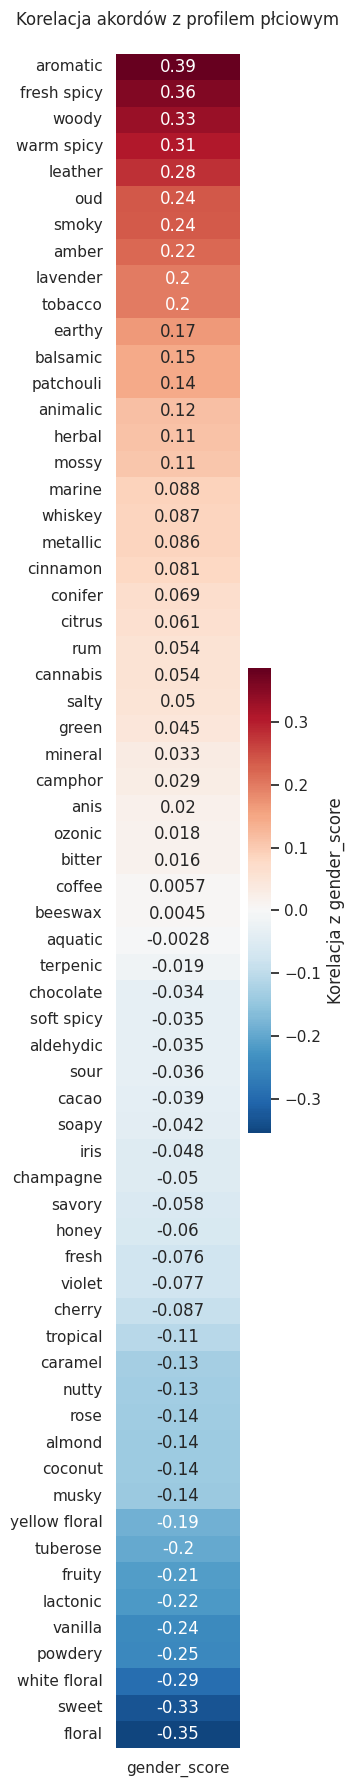

In [ ]:
# Heatmapa dla korelacji
corr_data = result_numerical[list(popular_accords) + ['gender_score']].corr()

gender_corr = corr_data[['gender_score']].drop(index='gender_score')

gender_corr.index = gender_corr.index.str.lower()
gender_corr = gender_corr.sort_values(by='gender_score', ascending=False)

plt.figure(figsize=(2, 22))
sns.heatmap(gender_corr, annot=True, cmap='RdBu_r', center=0, cbar_kws={'label': 'Korelacja z gender_score'})
plt.title('Korelacja akordów z profilem płciowym\n')
plt.show()

# Podsumowanie i Wnioski

Celem analizy była próba kategoryzacji zapachów typu **unisex** na podstawie ich akordów zapachowych oraz głosów społeczności portalu Fragrantica.   


### Kluczowe spostrzeżenia:
1. Model Random Forest osiągnął wynik $R^2 \approx 0.64$, co oznacza, że same akordy zapachowe wyjaśniają aż 64% zmienności w tym, jak ludzie postrzegają płciowość zapachu.
2. Analiza korelacji potwierdziła klasyczny podział w perfumiarstwie. Akordy **kwiatowe, słodkie i pudrowe** są niezmiennie kojarzone z profilem kobiecym, podczas gdy nuty **aromatyczne, drzewne i korzenne** definiują profil męski.
3. Większość zapachów unisex oscyluje wokół środka skali (2.0).